# Here we test the functionality to check the transformation between behavioral data and EEG grid

In [2]:
from metamers.behavioral.plotting import load_behavior_table
from metamers.EEGbeh.grid_mapping import *
from metamers.eeg.ssvep_plotting import *
import matplotlib.pyplot as plt


protans = ["MET016","MET017","MET028", "MET031", "MET036"]
deutans = ["MET015", "MET029", "MET032", "MET033", "MET034"]

# 1. load and select the group of participants for CTR, PD, protan, deutan
beh = load_behavior_table()
df_CTR = beh[beh["PartType"] == 1]
df_PD  = beh[beh["PartType"] == 3]
df_protan = beh[beh["SubID"].isin(protans) ]
df_deutan = beh[beh["SubID"].isin(deutans)]
# 2. Convert behavioral points → grid matrix
points = df_CTR[["Red", "Green"]].to_numpy()
_, BCTR = closest_grid_indices(points)

points = df_PD[["Red", "Green"]].to_numpy()
_, BPD = closest_grid_indices(points)

points = df_protan[["Red", "Green"]].to_numpy()
_, Bpro = closest_grid_indices(points)

points = df_deutan[["Red", "Green"]].to_numpy()
_, Bdeu = closest_grid_indices(points)

# 3. Load the EEG metadata
npz_root = "/home/zevaz/projects/metamers/eeg/ssveps"
df_meta = load_metadata(npz_root)

# 4. Load EEG group maps
ECTR, _ = compute_group_mean_map(df_meta, "CTR",normalize=True)
EPD, _ = compute_group_mean_map(df_meta, "PD",normalize=True)
Epro, _ = compute_group_mean_map(df_meta, "protan",normalize=True)
Edeu, _ = compute_group_mean_map(df_meta, "deutan",normalize=True)



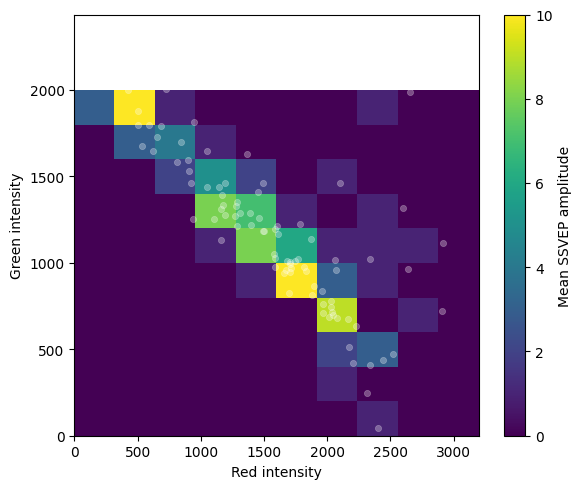

In [3]:
RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])
cmap="viridis"

plt.figure(figsize=(6, 5))

# Heatmap with optional color scale control
plt.imshow(
    Bdeu,
    origin="lower",
    cmap=cmap,
    extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
    aspect="auto"
)
plt.colorbar(label="Mean SSVEP amplitude")

# Overlay scatter points
plt.scatter(
    df_deutan["Red"],
    df_deutan["Green"],
    c="#FFFFFF",
    s=20,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.3
)
plt.xlabel("Red intensity")
plt.ylabel("Green intensity")
plt.tight_layout()
plt.show()

In [4]:
RED = np.array([0, 355.6, 711.1, 1066.7, 1422.2, 1777.8, 2133.3, 2488.9, 2844.4, 3200.0])
GREEN = np.array([0, 222.2, 444.4, 666.7, 888.9, 1111.1, 1333.3, 1555.6, 1777.8, 2000.0])
cmap = "viridis"

def plot_behavior_and_eeg(B, E, df_beh, vmin=None, vmax=None):
    """
    Left: behavioral occupancy matrix B + scatter
    Right: EEG map E
    Both use the same RED/GREEN axes.
    """

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # -------------------------
    # LEFT PANEL — Behavioral
    # -------------------------
    ax = axes[0]
    im1 = ax.imshow(
        B,
        origin="lower",
        cmap=cmap,
        extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.scatter(
        df_beh["Red"],
        df_beh["Green"],
        c="#FFFFFF",
        s=20,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.3
    )
    ax.set_xlim(0, 3200)
    ax.set_ylim(0, 2000)
    ax.set_title("Behavioral occupancy")
    ax.set_xlabel("Red intensity")
    ax.set_ylabel("Green intensity")

    fig.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)

    # -------------------------
    # RIGHT PANEL — EEG
    # -------------------------
    ax = axes[1]
    im2 = ax.imshow(
        E,
        origin="lower",
        cmap=cmap,
        extent=[RED.min(), RED.max(), GREEN.min(), GREEN.max()],
        aspect="auto",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_xlim(0, 3200)
    ax.set_ylim(0, 2000)
    ax.set_title("EEG map")
    ax.set_xlabel("Red intensity")
    ax.set_ylabel("Green intensity")

    fig.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


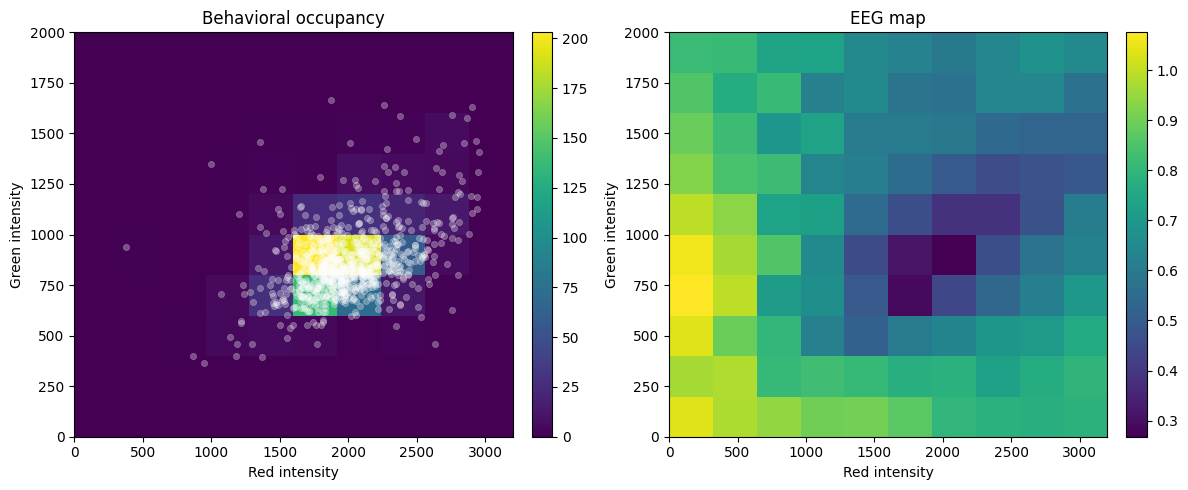

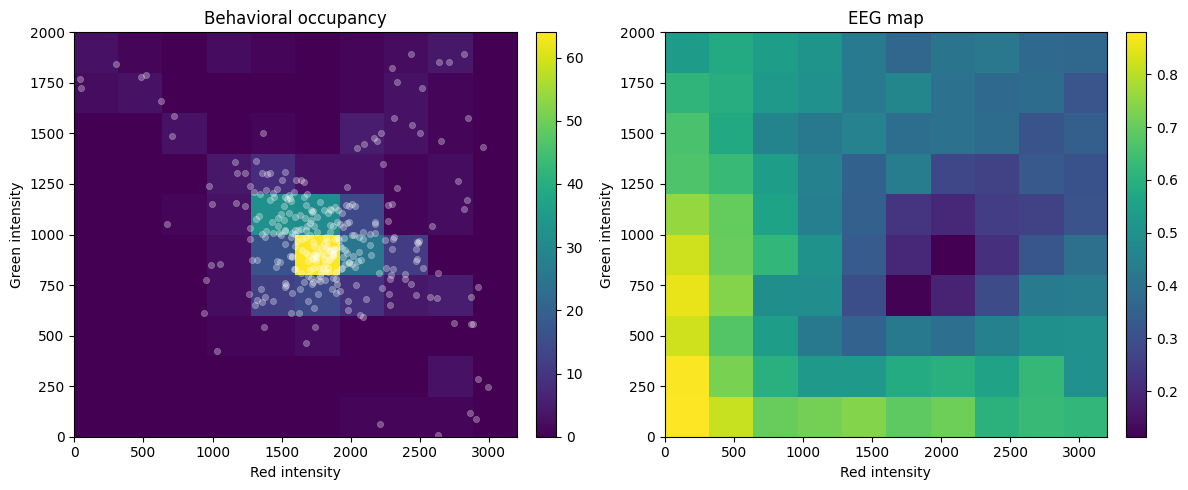

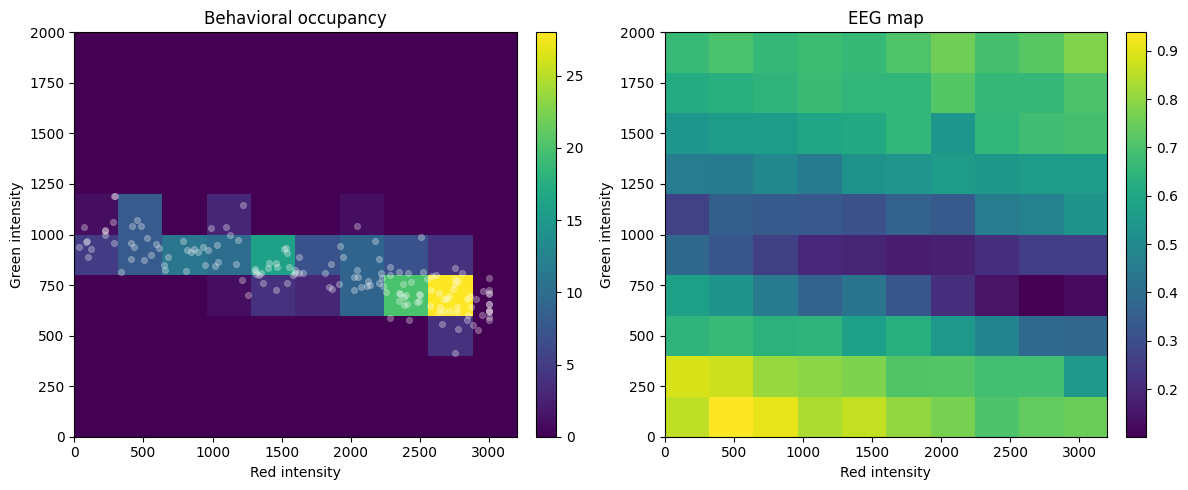

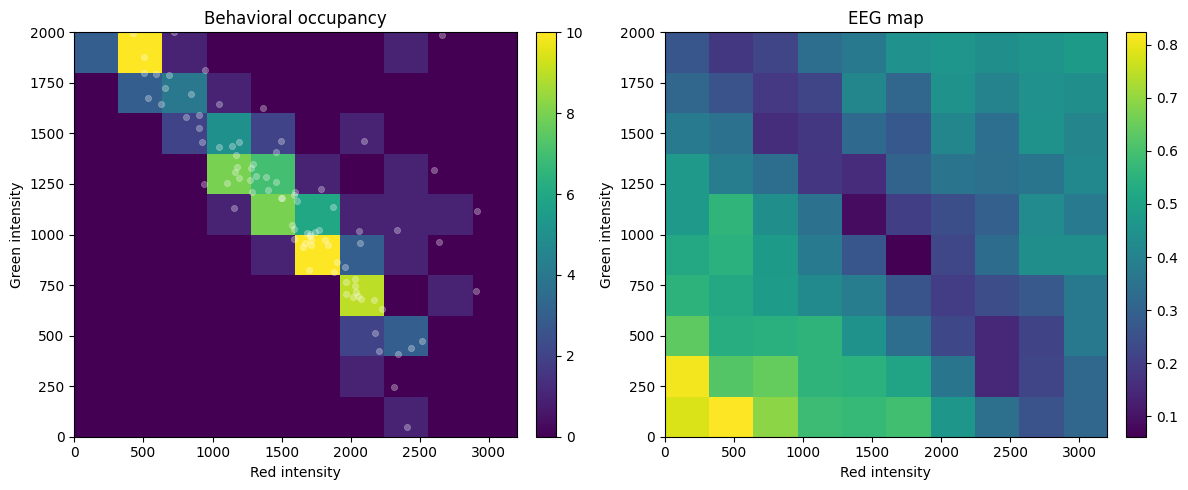

In [5]:
# B = behavioral occupancy matrix (10×10)
# ECTR = EEG map for CTR group (10×10)

plot_behavior_and_eeg(
    BCTR,
    ECTR,
    df_CTR,
)

plot_behavior_and_eeg(
    BPD,
    EPD,
    df_PD,
)

plot_behavior_and_eeg(
    Bpro,
    Epro,
    df_protan,
)

plot_behavior_and_eeg(
    Bdeu,
    Edeu,
    df_deutan,
)

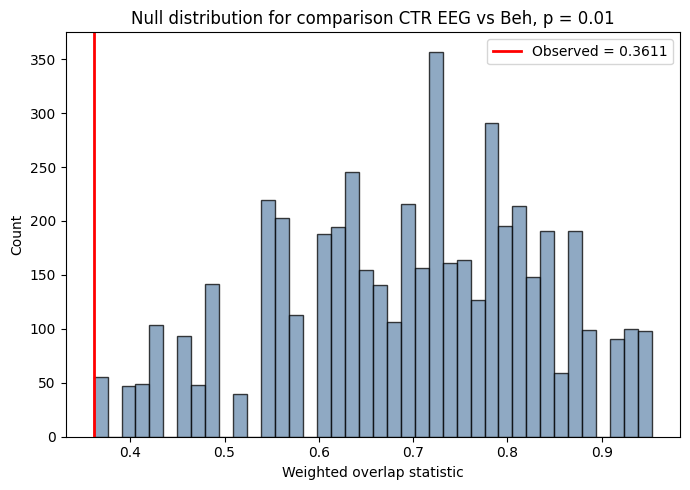

Result permutated Controls, p = 0.011  obs Stat = 0.3611186790408344


In [19]:
p, obs, null = permWeighted2Dshifts(BCTR, ECTR, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison CTR EEG vs Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated Controls, p =", p, " obs Stat =", obs)


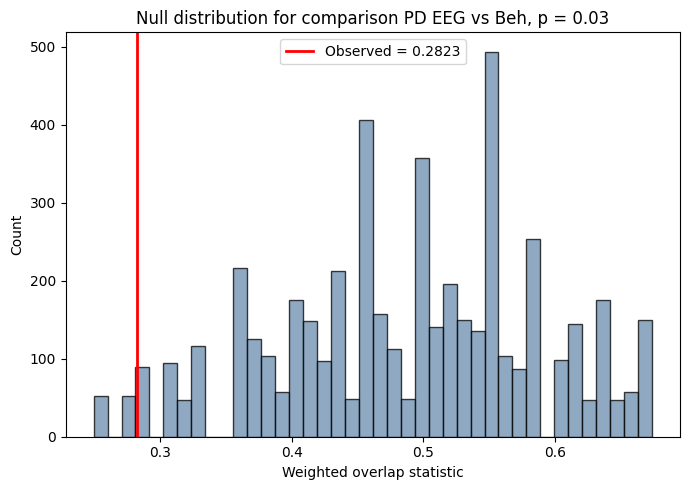

Result permutated PD, p = 0.0306  obs Stat = 0.28231907494324804


In [13]:
p, obs, null = permWeighted2Dshifts(BPD, EPD, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison PD EEG vs Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated PD, p =", p, " obs Stat =", obs)


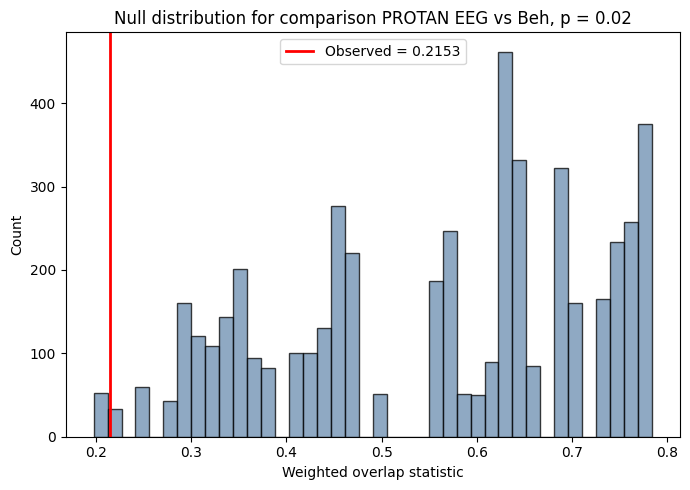

Result permutated Protan, p = 0.0172  obs Stat = 0.2153292670915682


In [14]:
p, obs, null = permWeighted2Dshifts(Bpro, Epro, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison PROTAN EEG vs Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated Protan, p =", p, " obs Stat =", obs)


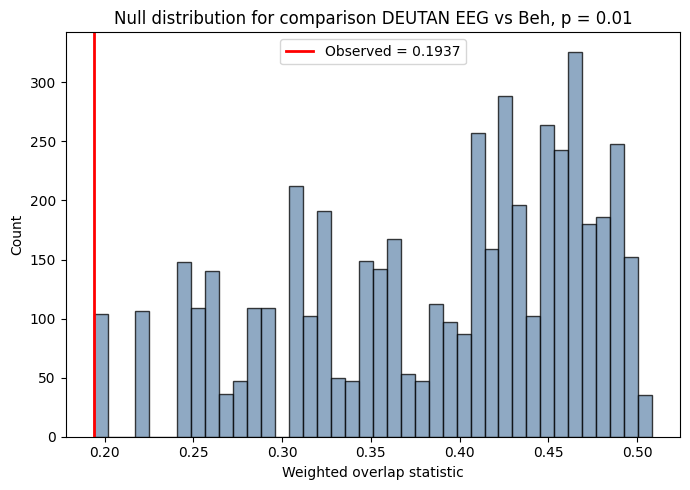

Result permutated Deutan, p = 0.0112  obs Stat = 0.19372739930056065


In [15]:
p, obs, null = permWeighted2Dshifts(Bdeu, Edeu, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison DEUTAN EEG vs Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated Deutan, p =", p, " obs Stat =", obs)


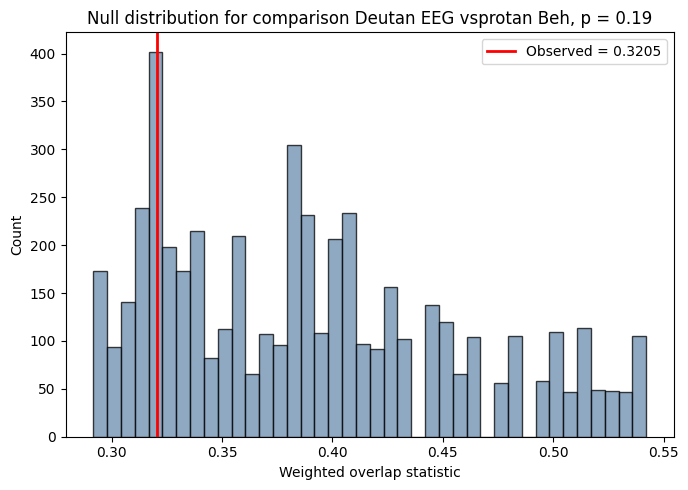

Result permutated Protan B, vs deutan E, p = 0.1896  obs Stat = 0.3204719287341


In [16]:
p, obs, null = permWeighted2Dshifts(Bpro, Edeu, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison Deutan EEG vsprotan Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated Protan B, vs deutan E, p =", p, " obs Stat =", obs)


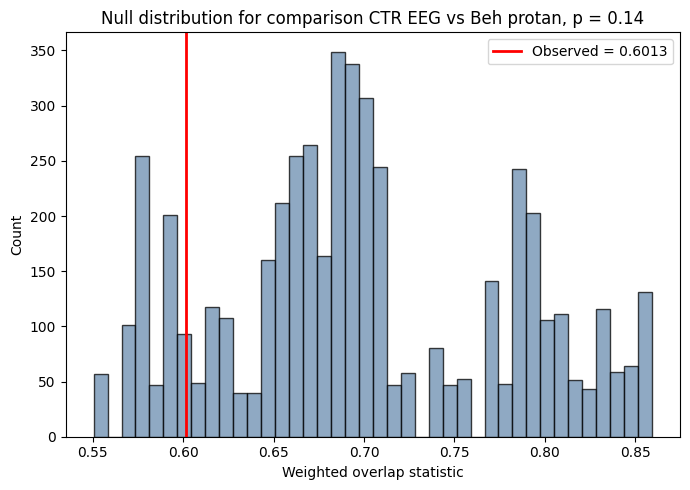

Result permutated E CTR vs Protan B, p = 0.1414  obs Stat = 0.6013383960254908


In [17]:
p, obs, null = permWeighted2Dshifts(Bpro, ECTR, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison CTR EEG vs Beh protan, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated E CTR vs Protan B, p =", p, " obs Stat =", obs)


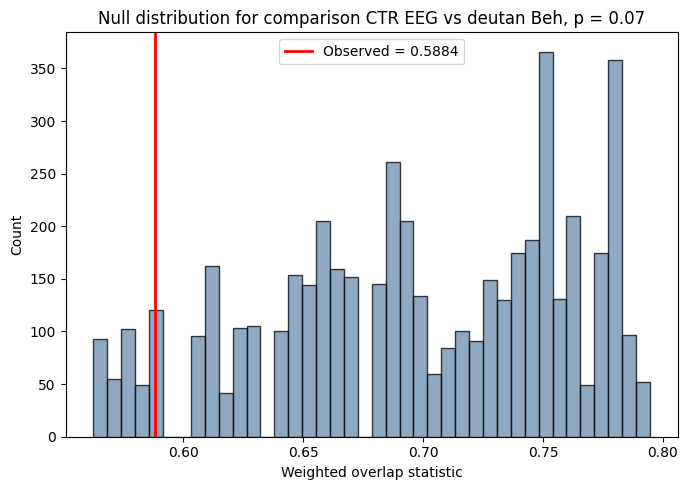

Result permutated E CTR vs B deutan, p = 0.0732  obs Stat = 0.5884073986816596


In [18]:
p, obs, null = permWeighted2Dshifts(Bdeu, ECTR, nPerm=5000)

plt.figure(figsize=(7, 5))
# Histogram
plt.hist(null, bins=40, color="#6a8caf", alpha=0.75, edgecolor="black")

# Observed statistic line
plt.axvline(obs, color="red", linewidth=2, label=f"Observed = {obs:.4f}")

plt.title(f"Null distribution for comparison CTR EEG vs deutan Beh, p = {p:.2f}")
plt.xlabel("Weighted overlap statistic")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

print("Result permutated E CTR vs B deutan, p =", p, " obs Stat =", obs)
